Total patients: 10000
High priority: 2026
Low priority : 7974

Fairness Results
---------------------------
Average Reward (High Priority): 3.6821
Average Reward (Low Priority) : -0.4876

Fairness Metrics
---------------------------
Absolute Fairness Gap: 4.1697
Relative Fairness Gap: 8.5518


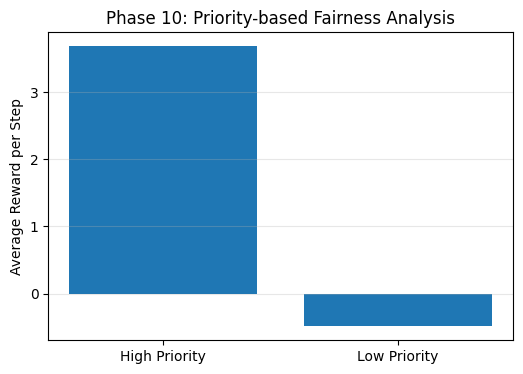


Fairness results saved to results/phase10_fairness_results.csv


In [2]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

# -----------------------
# Path Setup
# -----------------------
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, PROJECT_ROOT)

from utils.hospital_env import HospitalEnv
from utils.models import DQN, normalize

# -----------------------
# Load Dataset
# -----------------------
DATA_PATH = os.path.join(PROJECT_ROOT, "data", "synthetic_hospital_data_10000.csv")
data = pd.read_csv(DATA_PATH)

print("Total patients:", len(data))
print("High priority:", len(data[data["priority"] == 1]))
print("Low priority :", len(data[data["priority"] == 0]))

# -----------------------
# Load Trained Model
# -----------------------
model = DQN()
model.load_state_dict(torch.load("models/ddqn_model.pt"))
model.eval()

# -----------------------
# Fairness Evaluation Function
# -----------------------
def evaluate_fairness(model, data):

    env = HospitalEnv(data)
    state = normalize(env.reset()).astype(np.float32)

    done = False

    hp_reward = 0
    lp_reward = 0
    hp_steps = 0
    lp_steps = 0

    while not done:

        # Choose action from trained model
        with torch.no_grad():
            state_tensor = torch.from_numpy(state).float().unsqueeze(0)
            action = torch.argmax(model(state_tensor), dim=1).item()

        # Get priority BEFORE stepping
        current_priority = env.data.iloc[env.current_index]["priority"]

        # Step environment
        next_state, reward, done, info = env.step(action)

        # Accumulate rewards by priority group
        if current_priority == 1:
            hp_reward += reward
            hp_steps += 1
        else:
            lp_reward += reward
            lp_steps += 1

        # Update state
        if not done:
            state = normalize(next_state).astype(np.float32)

    # Average rewards
    avg_hp = hp_reward / hp_steps if hp_steps > 0 else 0
    avg_lp = lp_reward / lp_steps if lp_steps > 0 else 0

    return avg_hp, avg_lp


# -----------------------
# Run Fairness Evaluation
# -----------------------
hp_reward, lp_reward = evaluate_fairness(model, data)

print("\nFairness Results")
print("---------------------------")
print(f"Average Reward (High Priority): {hp_reward:.4f}")
print(f"Average Reward (Low Priority) : {lp_reward:.4f}")

# -----------------------
# Fairness Metrics
# -----------------------
fairness_gap = abs(hp_reward - lp_reward)
relative_gap = fairness_gap / (abs(lp_reward) + 1e-6)

print("\nFairness Metrics")
print("---------------------------")
print(f"Absolute Fairness Gap: {fairness_gap:.4f}")
print(f"Relative Fairness Gap: {relative_gap:.4f}")

# -----------------------
# Visualization
# -----------------------
plt.figure(figsize=(6,4))
plt.bar(["High Priority", "Low Priority"], [hp_reward, lp_reward])
plt.ylabel("Average Reward per Step")
plt.title("Phase 10: Priority-based Fairness Analysis")
plt.grid(axis="y", alpha=0.3)
plt.savefig("phase10_fairness_plot.png")
plt.show()

# -----------------------
# Save Results
# -----------------------
os.makedirs("results", exist_ok=True)

results_df = pd.DataFrame({
    "group": ["High Priority", "Low Priority"],
    "avg_reward": [hp_reward, lp_reward],
    "fairness_gap": [fairness_gap, fairness_gap],
    "relative_gap": [relative_gap, relative_gap]
})

results_df.to_csv("results/phase10_fairness_results.csv", index=False)

print("\nFairness results saved to results/phase10_fairness_results.csv")

# Interpretation